### F1&Recall (Python)

In [ ]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd


# Replace this with your preferred output folder.
OUTPUT_DIR = Path("path/to/output/segmentation_evaluation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "font.size": 7,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    }
)


def save_figure(fig: mpl.figure.Figure, out_prefix: Path, dpi: int = 600) -> None:
    fig.savefig(out_prefix.with_suffix(".png"), dpi=dpi, bbox_inches="tight")
    fig.savefig(out_prefix.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(out_prefix.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(out_prefix.with_suffix(".tiff"), dpi=dpi, bbox_inches="tight")


def build_segmentation_table() -> pd.DataFrame:
    # Visual counting results.
    # gt: number of manually annotated cells.
    # pred: number of predicted cell contours.
    # tp: ground-truth cells successfully detected.
    # fn: missed ground-truth cells.
    # fp: extra predicted contours.

    df["recall"] = df["tp"] / (df["tp"] + df["fn"])
    df["precision"] = df["tp"] / (df["tp"] + df["fp"])
    df["f1"] = 2 * df["precision"] * df["recall"] / (df["precision"] + df["recall"])
    return df


def plot_recall_f1_bar(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame(
        [
            {"metric": "Recall", "mean": df["recall"].mean(), "se": df["recall"].sem()},
            {"metric": "F1", "mean": df["f1"].mean(), "se": df["f1"].sem()},
        ]
    )

    fig, ax = plt.subplots(figsize=(2.05, 2.25))
    colors = ["#2AA876", "#F58518"]
    bars = ax.bar(
        summary["metric"],
        summary["mean"],
        yerr=summary["se"],
        capsize=2.8,
        color=colors,
        edgecolor="none",
        width=0.58,
        error_kw={"elinewidth": 0.8, "capthick": 0.8},
    )

    for bar, value in zip(bars, summary["mean"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.035,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.08)
    ax.set_title("Segmentation performance", fontsize=8, pad=5)
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.35)
    fig.tight_layout()
    save_figure(fig, OUTPUT_DIR / "segmentation_recall_f1_bar")
    plt.close(fig)

    return summary


def main() -> None:
    sample_metrics = build_segmentation_table()
    summary = plot_recall_f1_bar(sample_metrics)

    sample_metrics.to_csv(OUTPUT_DIR / "segmentation_sample_metrics.csv", index=False)
    summary.to_csv(OUTPUT_DIR / "segmentation_recall_f1_summary.csv", index=False)

    print(summary.to_string(index=False))
    print(f"Results saved to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()


### R

In [1]:
library(ggplot2)
library(tidyverse)
library(ggrepel)
library(Seurat)
best_color <- c("#9571d9", "#FF8B88", "#9BC48C", "#9BC48C", "#E6AB02" ,
                "#fd7c01", "#DA5E05", "#8B0201", "#FCB462",
                "#a4cee1",  "#02bdfe","#08529d", "#108b96", 
                "#199a73","#CBEAC4",  "#32a02d",  "#B15928")#,"#E41A1C"

order = c("EX_DG",'EX_CA1','EX_CA2','EX_CA3-4','EX_Sub',
          'IN_LAMP5','IN_PVALB',"IN_SST",'IN_VIP',
          "Oligo","OPC","Astro","Micro",
          'Endo','Pericyte','Fibroblast','Ependy')
names(best_color) = order

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Attaching SeuratObject



In [2]:
data = readRDS('/data/users/liuyuyang/online/08.脑区划分/01.data/AD.cellbin.allchips.merge.rds')

In [3]:
data$group <- ifelse(grepl("^AD", data$chip), "AD",
                     ifelse(grepl("^Con", data$chip), "Con", NA))

table(data$group, useNA = "ifany")


    AD    Con 
913836 953923 

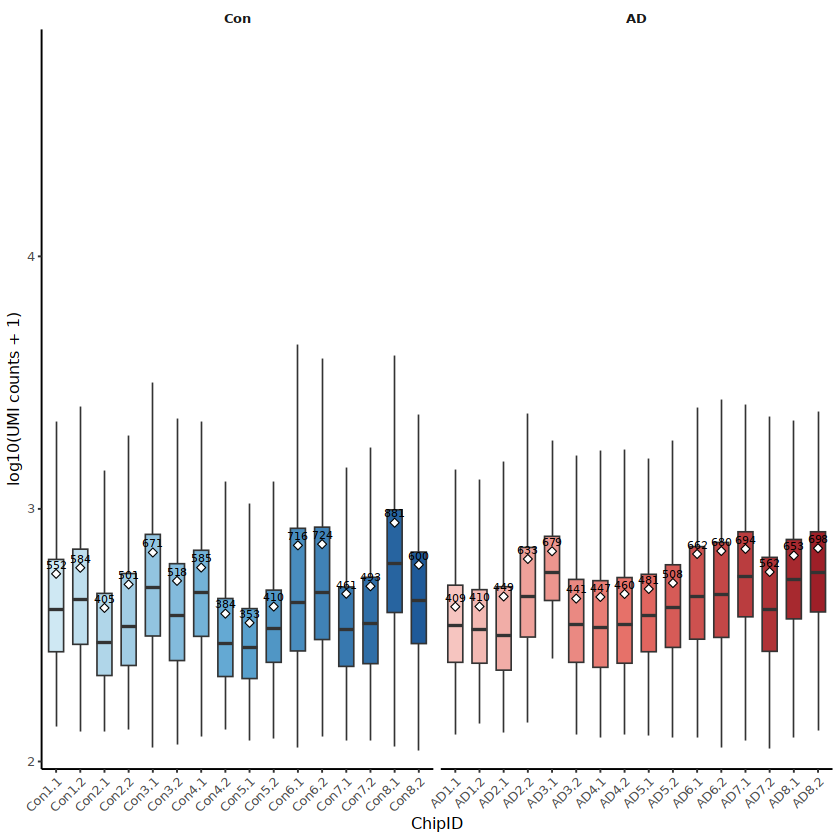

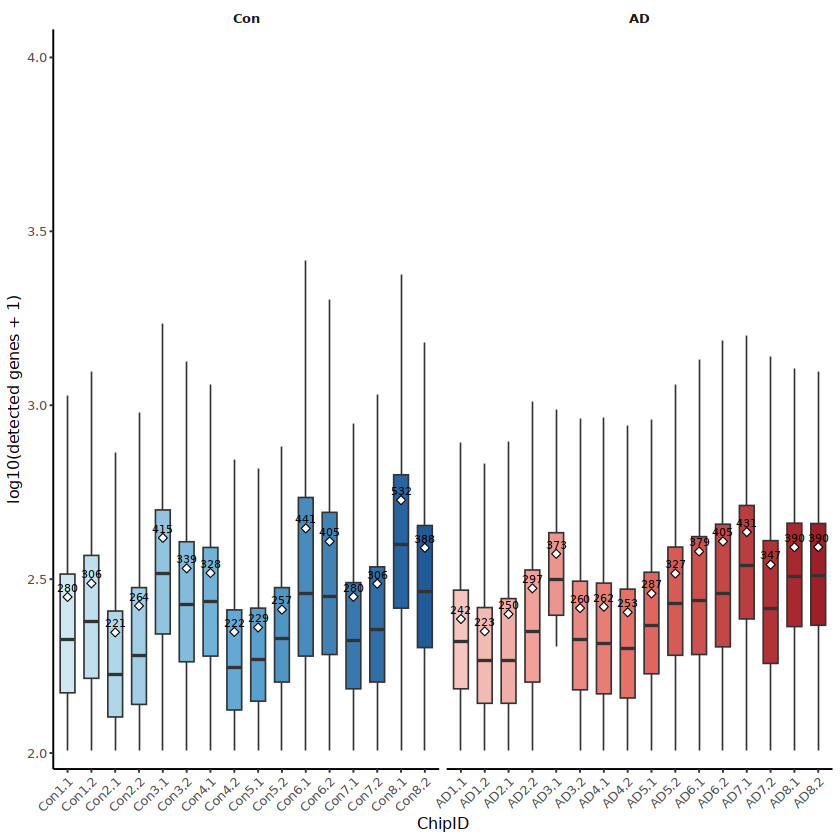

In [4]:
library(dplyr)
library(ggplot2)

meta <- data@meta.data

qc_df <- meta %>%
  dplyr::filter(group %in% c("AD", "Con")) %>%
  dplyr::mutate(
    group = factor(group, levels = c("Con", "AD")),
    ChipID = as.character(chip),
    log_counts = log10(nCount_RNA + 1),
    log_genes = log10(nFeature_RNA + 1)
  )

# 原始均值，用于图中标注
mean_df <- qc_df %>%
  dplyr::group_by(group, ChipID) %>%
  dplyr::summarise(
    mean_counts_raw = mean(nCount_RNA, na.rm = TRUE),
    mean_genes_raw = mean(nFeature_RNA, na.rm = TRUE),
    mean_counts_y = log10(mean_counts_raw + 1),
    mean_genes_y = log10(mean_genes_raw + 1),
    .groups = "drop"
  )

# Con 用蓝色渐变，AD 用红色渐变
con_chips <- unique(qc_df$ChipID[qc_df$group == "Con"])
ad_chips  <- unique(qc_df$ChipID[qc_df$group == "AD"])

con_cols <- colorRampPalette(c("#CFE8F3", "#5DA5D1", "#1F5A99"))(length(con_chips))
ad_cols  <- colorRampPalette(c("#F6C5C0", "#E56B63", "#9E1F28"))(length(ad_chips))

chip_cols <- c(
  setNames(con_cols, con_chips),
  setNames(ad_cols, ad_chips)
)

p_counts <- ggplot(qc_df, aes(x = ChipID, y = log_counts, fill = ChipID)) +
  geom_boxplot(width = 0.62, outlier.shape = NA, linewidth = 0.35) +
  geom_point(
    data = mean_df,
    aes(x = ChipID, y = mean_counts_y),
    inherit.aes = FALSE,
    shape = 23,
    size = 1.8,
    fill = "white",
    colour = "black",
    stroke = 0.35
  ) +
  geom_text(
    data = mean_df,
    aes(
      x = ChipID,
      y = mean_counts_y,
      label = round(mean_counts_raw)
    ),
    inherit.aes = FALSE,
    vjust = -0.65,
    size = 2.2
  ) +
  facet_wrap(~ group, scales = "free_x", nrow = 1) +
  scale_fill_manual(values = chip_cols) +
  scale_y_continuous(expand = expansion(mult = c(0.03, 0.14))) +
  theme_classic(base_size = 9) +
  theme(
    legend.position = "none",
    strip.background = element_blank(),
    strip.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)
  ) +
  labs(x = "ChipID", y = "log10(UMI counts + 1)")

p_counts


p_genes <- ggplot(qc_df, aes(x = ChipID, y = log_genes, fill = ChipID)) +
  geom_boxplot(width = 0.62, outlier.shape = NA, linewidth = 0.35) +
  geom_point(
    data = mean_df,
    aes(x = ChipID, y = mean_genes_y),
    inherit.aes = FALSE,
    shape = 23,
    size = 1.8,
    fill = "white",
    colour = "black",
    stroke = 0.35
  ) +
  geom_text(
    data = mean_df,
    aes(
      x = ChipID,
      y = mean_genes_y,
      label = round(mean_genes_raw)
    ),
    inherit.aes = FALSE,
    vjust = -0.65,
    size = 2.2
  ) +
  facet_wrap(~ group, scales = "free_x", nrow = 1) +
  scale_fill_manual(values = chip_cols) +
  scale_y_continuous(expand = expansion(mult = c(0.03, 0.14))) +
  theme_classic(base_size = 9) +
  theme(
    legend.position = "none",
    strip.background = element_blank(),
    strip.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)
  ) +
  labs(x = "ChipID", y = "log10(detected genes + 1)")

p_genes
ggsave(
  filename = "AD_Con_log_UMI_counts_by_chip.pdf",
  plot = p_counts,
  width = 180,
  height = 80,
  units = "mm",
  device = cairo_pdf
)

ggsave(
  filename = "AD_Con_log_detected_genes_by_chip.pdf",
  plot = p_genes,
  width = 180,
  height = 80,
  units = "mm",
  device = cairo_pdf
)

In [56]:
library(patchwork)

p_qc <- p_counts / p_genes

ggsave(
  filename = "AD_Con_log_QC_by_chip.pdf",
  plot = p_qc,
  width = 180,
  height = 150,
  units = "mm",
  device = cairo_pdf
)

In [18]:
data1 <- readRDS("/data/users/liuyuyang/online/08.脑区划分/01.data/AD.cellbin.16chips.CA1_Sub.merge.CellType.rds")


In [39]:
head(data1)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,percent.mt,cellid,chip,CellType,CellType_sub,⋯,SCT_snn_res.0.5,SCT_snn_res.0.8,SCT_snn_res.1.2,SCT_snn_res.2,seurat_clusters,coor_y,coor_x,xy,CellType_batch4_m,group
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
22084_3,Spatial,222,133,222,133,3.153153,22084,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD
22086_3,Spatial,150,101,150,101,2.666667,22086,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD
22097_3,Spatial,229,142,229,142,3.930131,22097,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD
22098_3,Spatial,764,405,764,405,1.308901,22098,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD
22100_3,Spatial,245,163,245,163,2.448980,22100,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD
22114_3,Spatial,231,147,231,147,6.060606,22114,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD
22115_3,Spatial,1037,565,1037,565,2.410800,22115,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD
22116_3,Spatial,253,160,253,160,3.162055,22116,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD
22124_3,Spatial,281,161,281,161,4.270463,22124,AD2.1,Micro,Micro,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,AD


In [48]:
data <- readRDS("/data/users/liuyuyang/online/08.脑区划分/01.data/AD.cellbin.16chips.CA1_Sub.merge.CellType.rds")


[1] "EX_DG"    "EX_CA2"   "EX_CA3-4"
character(0)


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


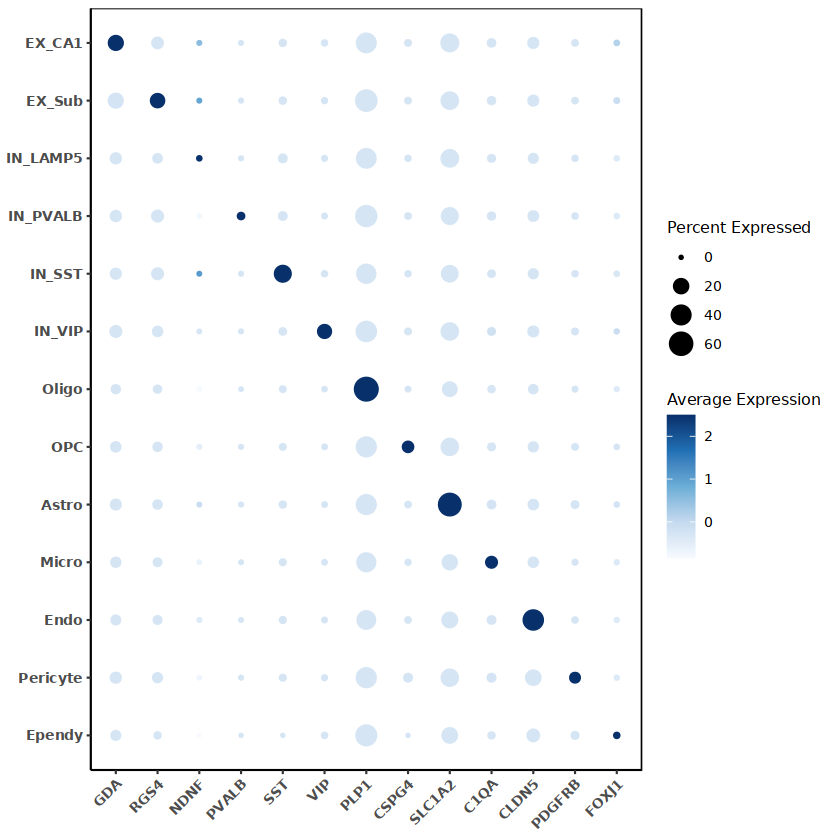

In [53]:
library(Seurat)
library(dplyr)
library(ggplot2)


DefaultAssay(data) <- "RNA"

order <- c(
  "EX_DG", "EX_CA1", "EX_CA2", "EX_CA3-4", "EX_Sub",
  "IN_LAMP5", "IN_PVALB", "IN_SST", "IN_VIP",
  "Oligo", "OPC", "Astro", "Micro",
  "Endo", "Pericyte", "Ependy"
)

marker_order <- c(
"GDA",             # EX_CA1
"RGS4",  # EX_Sub / EX
"NDNF",         # IN_LAMP5
"PVALB",           # IN_PVALB
"SST",     # IN_SST
"VIP",             # IN_VIP
"PLP1",            # Oligo
"CSPG4",          # OPC
"SLC1A2",          # Astro
"C1QA",        # Micro
"CLDN5",           # Endo
"PDGFRB",          # Pericyte
"FOXJ1"            # Ependy
)

celltype_use <- order[order %in% unique(as.character(data$CellType))]
missing_celltype <- setdiff(order, celltype_use)
print(missing_celltype)

marker_use <- marker_order[marker_order %in% rownames(data)]
missing_marker <- setdiff(marker_order, marker_use)
print(missing_marker)

data <- subset(data, subset = CellType %in% celltype_use)
data$CellType <- factor(data$CellType, levels = celltype_use)
Idents(data) <- "CellType"

p_dot <- DotPlot(
  object = data,
  features = marker_use,
  group.by = "CellType",
  assay = "RNA",
  dot.scale = 7
) +
  scale_x_discrete(limits = marker_use) +
  scale_y_discrete(limits = rev(celltype_use)) +
  scale_color_gradientn(
    colours = c("#f7fbff", "#c6dbef", "#6baed6", "#2171b5", "#08306b"),
    name = "Average\nExpression"
  ) +
  scale_size(
    range = c(0.5, 6),
    name = "Percent\nExpressed"
  ) +
  theme_classic(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, face = "bold"),
    axis.text.y = element_text(face = "bold"),
    axis.title = element_blank(),
    legend.title = element_text(size = 9),
    legend.text = element_text(size = 8),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.35)
  ) +
  labs(x = NULL, y = NULL)

p_dot

ggsave(
  filename = "CellType_marker_dotplot_ordered_diagonal.pdf",
  plot = p_dot,
  width = 11,
  height = 6.5,
  units = "in",
  device = cairo_pdf
)

In [58]:
library(Seurat)
library(dplyr)
library(ComplexHeatmap)
library(circlize)
library(grid)

data <- readRDS("/data/users/liuyuyang/online/08.脑区划分/01.data/AD.cellbin.16chips.CA1_Sub.merge.CellType.rds")

DefaultAssay(data) <- "RNA"

celltype_order <- c(
  "EX_DG", "EX_CA1", "EX_CA2", "EX_CA3-4", "EX_Sub",
  "IN_LAMP5", "IN_PVALB", "IN_SST", "IN_VIP",
  "Oligo", "OPC", "Astro", "Micro",
  "Endo", "Pericyte", "Ependy"
)

marker_order <- c(
"GDA",             # EX_CA1
"RGS4",  # EX_Sub / EX
"NDNF",         # IN_LAMP5
"PVALB",           # IN_PVALB
"SST",     # IN_SST
"VIP",             # IN_VIP
"PLP1",            # Oligo
"CSPG4",          # OPC
"SLC1A2",          # Astro
"C1QA",        # Micro
"CLDN5",           # Endo
"PDGFRB",          # Pericyte
"FOXJ1"            # Ependy
)
celltype_use <- celltype_order[celltype_order %in% unique(as.character(data$CellType))]
marker_use <- marker_order[marker_order %in% rownames(data)]

print(setdiff(celltype_order, celltype_use))
print(setdiff(marker_order, marker_use))

data <- subset(data, subset = CellType %in% celltype_use)
data$CellType <- factor(data$CellType, levels = celltype_use)
Idents(data) <- "CellType"

avg_exp <- AverageExpression(
  object = data,
  assays = "RNA",
  features = marker_use,
  group.by = "CellType",
  slot = "data"
)$RNA

avg_exp <- avg_exp[marker_use, celltype_use, drop = FALSE]

# 每个 marker 按 cell type 做 z-score，突出细胞类型特异性
mat_scaled <- t(scale(t(as.matrix(avg_exp))))
mat_scaled[is.na(mat_scaled)] <- 0
mat_scaled[mat_scaled > 2.5] <- 2.5
mat_scaled[mat_scaled < -2.5] <- -2.5

col_fun <- colorRamp2(
  c(-2.5, 0, 2.5),
  c("#F7F7F7", "#D9EAF7", "#08306B")
)

celltype_class <- c(
  EX_DG = "Excitatory",
  EX_CA1 = "Excitatory",
  EX_CA2 = "Excitatory",
  `EX_CA3-4` = "Excitatory",
  EX_Sub = "Excitatory",
  IN_LAMP5 = "Inhibitory",
  IN_PVALB = "Inhibitory",
  IN_SST = "Inhibitory",
  IN_VIP = "Inhibitory",
  Oligo = "Glia",
  OPC = "Glia",
  Astro = "Glia",
  Micro = "Immune",
  Endo = "Vascular",
  Pericyte = "Vascular",
  Fibroblast = "Vascular",
  Ependy = "Ependymal"
)

celltype_class <- celltype_class[celltype_use]

class_col <- c(
  Excitatory = "#4C78A8",
  Inhibitory = "#D65F5F",
  Glia = "#59A14F",
  Immune = "#8E6BBE",
  Vascular = "#E6A23C",
  Ependymal = "#6F6F6F"
)

ha_col <- HeatmapAnnotation(
  Class = celltype_class,
  col = list(Class = class_col),
  annotation_name_gp = gpar(fontsize = 8, fontface = "bold"),
  annotation_legend_param = list(
    title_gp = gpar(fontsize = 8, fontface = "bold"),
    labels_gp = gpar(fontsize = 7)
  )
)

ht <- Heatmap(
  mat_scaled,
  name = "Scaled\nexpression",
  col = col_fun,
  top_annotation = ha_col,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
  row_names_side = "left",
  column_names_side = "bottom",
  row_names_gp = gpar(fontsize = 9, fontface = "bold"),
  column_names_gp = gpar(fontsize = 9, fontface = "bold"),
  column_names_rot = 45,
  rect_gp = gpar(col = "white", lwd = 0.8),
  border = TRUE,
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = 8, fontface = "bold"),
    labels_gp = gpar(fontsize = 7),
    legend_height = unit(32, "mm")
  )
)

pdf("CellType_marker_heatmap_Nature_style.pdf", width = 8.5, height = 6.2, useDingbats = FALSE)
draw(
  ht,
  heatmap_legend_side = "right",
  annotation_legend_side = "right",
  padding = unit(c(4, 4, 4, 4), "mm")
)
dev.off()

[1] "EX_DG"    "EX_CA2"   "EX_CA3-4"
character(0)


png 
  2